The notebook contains examples on how to load spikes from .npy files. Loaded spikes are stored in .csv file (all units from all mice).

It plots some summary information about the dataset. The plot is saved in the figures google drive folder.

In [1]:
import numpy as np
import pandas as pd
import csv
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

#### Parameters

In [2]:
# your path to the dataset
dataset_folder = Path('/mnt/c/Users/Alina/Documents/ridetecives/brainhack/brainhack-dataset/')

#### Helper functions

Includes two ways of loading the whole dataset (18 mice):
* store all units from all mice in .csv file. One row corresponds to one unit and has the following format: [mouse_id, cluster_id, brain_area, rec_len_sec, spikes]
* store all units from all mice in pandas dataframe (.pkl file). One row corresponds to one spike and has the following format (df columns): [spikes, brain_area, clusters, num_rec, len_rec]

#### store all units from all mice in .csv file.

In [3]:
def load_mouse_data(mouse_id: int, dataset_folder: Path, verbose: bool = True):
    """
    Load spikes, cluster IDs, and brain areas for a given mouse folder.

    Parameters
    ----------
    mouse_id : int
        Identifier of the mouse (folder name).
    dataset_folder : Path
        Root dataset folder.
    verbose : bool
        If True, print dataset shapes/info.

    Returns
    -------
    dict
        key is cluster_id, value is { 'spikes': [...], 'brain_area': int}
    """
    mouse_folder = dataset_folder / str(mouse_id)
    if verbose:
        print(f"Loading mouse {mouse_id} from {mouse_folder}")

    # file paths
    brain_areas_file = mouse_folder / "brain_area.npy"
    cluster_ids_file = mouse_folder / "clusters.npy"
    spikes_file = mouse_folder / "spikes.npy"

    # load arrays
    brain_areas = np.load(brain_areas_file, allow_pickle=True).item()
    cluster_ids = np.load(cluster_ids_file)
    spikes = np.load(spikes_file)

    if verbose:
        print(f"brain_areas keys: {list(brain_areas.keys())}")
        print(f"brain_area cluster_id shape: {brain_areas['cluster_id'].shape}")
        print(f"brain_area names shape: {brain_areas['brain_area'].shape}")
        print(f"cluster_ids shape: {cluster_ids.shape}, "
              f"unique clusters: {len(np.unique(cluster_ids))}")
        print(f"spikes shape: {spikes.shape}")

    # build brain area map
    brain_area_map = dict(zip(brain_areas["cluster_id"], brain_areas["brain_area"]))

    # organize spikes per cluster
    cluster_data = {}
    for cid, spike in zip(cluster_ids, spikes):
        cluster_data.setdefault(cid, {"spikes": [], "brain_area": brain_area_map[cid]})
        cluster_data[cid]["spikes"].append(spike)

    return cluster_data


def load_all_mice(dataset_folder: str | Path, n_mice: int = 18, verbose: bool = True):
    """
    Load spikes for all mice.

    Returns
    -------
    dict
        key is mouse_id (folder name), value is cluster_data
    """
    dataset_folder = Path(dataset_folder)
    all_data = {}
    for mouse_id in range(1, n_mice + 1):
        all_data[mouse_id] = load_mouse_data(mouse_id, dataset_folder, verbose=verbose)
    return all_data


def export_spikes_to_csv(spikes_dataset_dict: dict, dataset_folder: str | Path, filename: str = "output/full_dataset.csv") -> Path:
    """
    Export spikes dataset dict to a CSV file.

    Parameters
    ----------
    spikes_dataset_dict : dict
        key is mouse_id (folder name), value is cluster_data.
    dataset_folder : str | Path
        Root dataset folder where the CSV will be saved.
    filename : str, default="output/full_dataset.csv"
        Relative path of the CSV file inside dataset_folder.

    Returns
    -------
    Path
        Path to the created CSV file.
    """
    dataset_folder = Path(dataset_folder)
    csv_path = dataset_folder / filename
    csv_path.parent.mkdir(parents=True, exist_ok=True) 

    with open(csv_path, mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["mouse_id", "cluster_id", "brain_area", "rec_len_sec", "spikes"])

        for mouse_id, clusters in spikes_dataset_dict.items():
            for cluster_id, data in clusters.items():
                spikes = data["spikes"]
                if not spikes:  # skip empty
                    continue
                rec_len_sec = spikes[-1]
                writer.writerow([
                    mouse_id,
                    cluster_id,
                    data["brain_area"],
                    rec_len_sec,
                    ";".join(map(str, spikes))
                ])

    print(f"CSV file '{csv_path}' has been created successfully!")
    return csv_path

#### store all units from all mice in pandas dataframe (.pkl file).

In [4]:
def get_spikes_area_clusters(num_rec, path_data=dataset_folder):
    spikes = np.load(path_data.joinpath(num_rec).joinpath('spikes.npy'))
    brainarea = np.load(path_data.joinpath(num_rec).joinpath('brain_area.npy'), allow_pickle=True)
    brainarea_d = brainarea.item()  # Convert numpy to dict
    clusters = np.load(path_data.joinpath(num_rec).joinpath('clusters.npy'), allow_pickle=True)
    return spikes, brainarea_d, clusters
    
def create_spike_table(spikes, brainarea_d, clusters):
    df = pd.DataFrame(columns=['spikes', 'brain_area', 'clusters'])
    df['spikes'] = spikes
    df['clusters'] = clusters
    mapping = dict(zip(brainarea_d["cluster_id"], brainarea_d["brain_area"]))
    df["brain_area"] = df["clusters"].map(mapping)
    return df
    
def create_df_1rec(num_rec, path_data=dataset_folder):
    spikes, brainarea_d, clusters = get_spikes_area_clusters(num_rec, path_data=path_data)
    df = create_spike_table(spikes, brainarea_d, clusters)
    df['num_rec'] = num_rec
    df['len_rec'] = spikes[-1] - spikes[0]
    return df
    
def get_spike_df(path_data=dataset_folder):
    for i_rec in range(1,19):  # RECORDING FROM 1-18
        df = create_df_1rec(str(i_rec), path_data=dataset_folder)
        if i_rec == 1:
            df_all = df.copy()
        else:
            df_all = pd.concat([df_all, df])  # Note this is a df with 44k rows

    return df_all

#### Loading spikes

In [5]:
spikes_dataset_dict = {
    2: load_mouse_data(2, dataset_folder, False)
}

export_spikes_to_csv(spikes_dataset_dict, dataset_folder, "output/full_dataset.csv")

spikes_df = create_df_1rec("2", path_data=dataset_folder)
spikes_df.to_pickle(dataset_folder / "output/full_dataset.pkl")

CSV file '/mnt/c/Users/Alina/Documents/ridetecives/brainhack/brainhack-dataset/output/full_dataset.csv' has been created successfully!


In [6]:
import os
print(os.getcwd())

/mnt/c/Users/Alina/Documents/ridetecives/brainhack


In [7]:
spikes_df

,spikes,brain_area,clusters,num_rec,len_rec
0,-6.444758,3,861,2,4655.352229
1,-6.435758,3,861,2,4655.352229
2,-6.433225,3,870,2,4655.352229
3,-6.406791,1,648,2,4655.352229
4,-6.401958,1,648,2,4655.352229
...,...,...,...,...,...
2650920,4648.901705,2,1298,2,4655.352229
2650921,4648.902205,2,1286,2,4655.352229
2650922,4648.903071,2,1300,2,4655.352229
2650923,4648.905238,2,1243,2,4655.352229


#### Ploting summary info

total units count 79


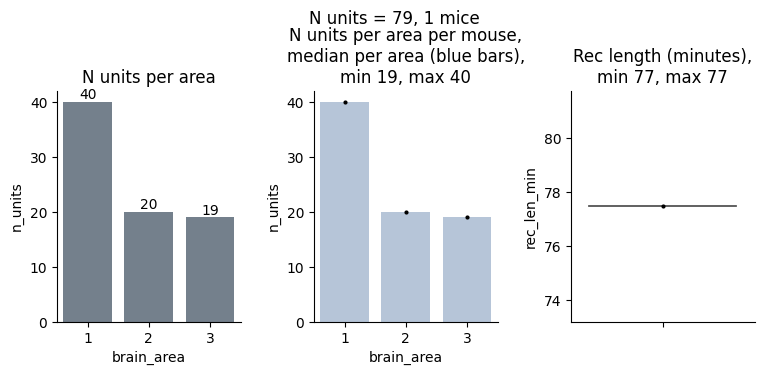

In [8]:
csv_filename = dataset_folder / "output/full_dataset.csv"
df = pd.read_csv(csv_filename, usecols=["mouse_id", "cluster_id", "brain_area", "rec_len_sec"])

# units per brain area
units_per_brain_area = (
    df.groupby("brain_area")["cluster_id"].count().reset_index(name="n_units")
)
mice_per_brain_area = (
    df.groupby("brain_area")["mouse_id"].nunique().reset_index(name="n_mice")
)
units_per_brain_area = pd.merge(units_per_brain_area, mice_per_brain_area, on="brain_area")
print(f"total units count {units_per_brain_area['n_units'].sum()}")

# units per area per mouse
units_per_brain_area_per_mouse = (
    df.groupby(["brain_area", "mouse_id"])["cluster_id"].count().reset_index(name="n_units")
)

# recording length per mouse 
rec_len_per_mouse = df.groupby("mouse_id")["rec_len_sec"].max().reset_index()
rec_len_per_mouse["rec_len_min"] = rec_len_per_mouse["rec_len_sec"] / 60

# plotting 
color = "slategrey"
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
plt.subplots_adjust(hspace=0.8, wspace=0.4)

# panel 0
sns.barplot(ax=axes[0], x="brain_area", y="n_units", data=units_per_brain_area, color=color)
axes[0].bar_label(axes[0].containers[0], fmt="%.0f")
axes[0].set_title("N units per area")

# panel 1
sns.stripplot(ax=axes[1], x="brain_area", y="n_units", data=units_per_brain_area_per_mouse,
              color="black", s=3)
median_units = (
    units_per_brain_area_per_mouse.groupby("brain_area")["n_units"].median()
    .apply(np.ceil).astype(int).reset_index()
)
sns.barplot(ax=axes[1], x="brain_area", y="n_units", data=median_units, color="lightsteelblue")
axes[1].set_title(
    f"N units per area per mouse,\n"
    f"median per area (blue bars),\n"
    f"min {units_per_brain_area_per_mouse['n_units'].min()}, "
    f"max {units_per_brain_area_per_mouse['n_units'].max()}"
)

# panel 2
sns.violinplot(ax=axes[2], y="rec_len_min", data=rec_len_per_mouse,
               cut=0, density_norm="width", color=color)
sns.stripplot(ax=axes[2], y="rec_len_min", data=rec_len_per_mouse, color="black", s=3)
axes[2].set_title(
    f"Rec length (minutes),\n"
    f"min {rec_len_per_mouse['rec_len_min'].min():.0f}, "
    f"max {rec_len_per_mouse['rec_len_min'].max():.0f}"
)

fig.suptitle(
    f"N units = {units_per_brain_area['n_units'].sum()}, "
    f"{df['mouse_id'].nunique()} mice", y=1.15
)
sns.despine()
fig.savefig(dataset_folder / "output/spikes_info.png", bbox_inches="tight")

In [9]:
# collect all trial_data.csv into one DataFrame
all_trials = []
# for ii in range(1, 19):
trialdata_filename = dataset_folder / str(2) / "trial_data.csv"
df_mouse = pd.read_csv(trialdata_filename).drop(columns="Unnamed: 0", errors="ignore")
df_mouse["trial_duration"] = df_mouse["trial_end"] - df_mouse["trial_start"]
df_mouse.insert(0, "mouse_id", 2)   # put mouse_id as the first column
all_trials.append(df_mouse)

trials_df = pd.concat(all_trials, ignore_index=True)
trials_df.to_csv(dataset_folder / 'output/trials_info.csv')

trials_df

,mouse_id,variable_A,variable_B,variable_C,trial_start,stim_start,outcome,trial_end,trial_duration
0,2,1,0,0,255.617567,263.146933,298.976567,300.046633,44.429067
1,2,1,1,2,301.153167,301.852800,302.264600,303.336200,2.183033
2,2,1,1,2,304.124500,307.563233,307.832233,308.902933,4.778433
3,2,0,0,2,309.775367,313.379867,313.692667,315.763033,5.987667
4,2,0,0,2,316.599733,317.319400,317.785300,319.846400,3.246667
...,...,...,...,...,...,...,...,...,...
845,2,1,0,0,3878.284533,3879.589167,3880.239933,3881.316433,3.031900
846,2,1,0,0,3882.807367,3883.455700,3883.750967,3884.822400,2.015033
847,2,0,1,0,3886.309400,3889.733067,3892.745600,3894.822300,8.512900
848,2,1,0,0,3896.358400,3899.599633,3905.146267,3906.205533,9.847133


In [10]:
trials_df["variable_C"].unique()

array([0, 2])

### Separate the spikes in three df

In [10]:
pre_spikes = []
stim_spikes = []
post_spikes = []

for i, trial in trials_df.iterrows():
    t_start = trial["trial_start"]
    t_stim = trial["stim_start"]
    t_outcome = trial["outcome"]
    t_end = trial["trial_end"]

    df_pre = spikes_df[
        (spikes_df["spikes"] >= t_start) & (spikes_df["spikes"] < t_stim)
    ].copy()
    df_pre["trial"] = i
    df_pre["segment"] = "pre"
    pre_spikes.append(df_pre)

    df_stim = spikes_df[
        (spikes_df["spikes"] >= t_stim) & (spikes_df["spikes"] < t_outcome)
    ].copy()
    df_stim["trial"] = i
    df_stim["segment"] = "stim"
    stim_spikes.append(df_stim)

    df_post = spikes_df[
        (spikes_df["spikes"] >= t_outcome) & (spikes_df["spikes"] < t_end)
    ].copy()
    df_post["trial"] = i
    df_post["segment"] = "post"
    post_spikes.append(df_post)

In [11]:
pre_df = pd.concat(pre_spikes, ignore_index=True)
stim_df = pd.concat(stim_spikes, ignore_index=True)
post_df = pd.concat(post_spikes, ignore_index=True)

In [12]:
print(pre_df[["trial", "segment"]].isna().sum())
print(stim_df[["trial", "segment"]].isna().sum())
print(post_df[["trial", "segment"]].isna().sum())

trial      0
segment    0
dtype: int64
trial      0
segment    0
dtype: int64
trial      0
segment    0
dtype: int64


In [13]:
pre_df

,spikes,brain_area,clusters,num_rec,len_rec,trial,segment
0,255.625351,3,1026,2,4655.352229,0,pre
1,255.626051,2,1238,2,4655.352229,0,pre
2,255.626218,3,1445,2,4655.352229,0,pre
3,255.632451,3,870,2,4655.352229,0,pre
4,255.632484,2,1264,2,4655.352229,0,pre
...,...,...,...,...,...,...,...
477922,3912.093704,1,634,2,4655.352229,849,pre
477923,3912.097638,1,619,2,4655.352229,849,pre
477924,3912.097838,1,632,2,4655.352229,849,pre
477925,3912.098104,2,1233,2,4655.352229,849,pre


In [14]:
stim_df

,spikes,brain_area,clusters,num_rec,len_rec,trial,segment
0,263.152943,1,627,2,4655.352229,0,stim
1,263.152943,1,625,2,4655.352229,0,stim
2,263.163343,1,630,2,4655.352229,0,stim
3,263.163776,1,654,2,4655.352229,0,stim
4,263.166143,3,1007,2,4655.352229,0,stim
...,...,...,...,...,...,...,...
452745,3915.069348,3,874,2,4655.352229,849,stim
452746,3915.070614,1,663,2,4655.352229,849,stim
452747,3915.071014,1,612,2,4655.352229,849,stim
452748,3915.072681,1,599,2,4655.352229,849,stim


In [15]:
post_df

,spikes,brain_area,clusters,num_rec,len_rec,trial,segment
0,298.979964,1,648,2,4655.352229,0,post
1,298.982064,1,619,2,4655.352229,0,post
2,298.983597,1,598,2,4655.352229,0,post
3,298.986164,1,671,2,4655.352229,0,post
4,298.987930,3,874,2,4655.352229,0,post
...,...,...,...,...,...,...,...
1031921,4618.339338,1,688,2,4655.352229,849,post
1031922,4618.339738,1,589,2,4655.352229,849,post
1031923,4618.339804,1,599,2,4655.352229,849,post
1031924,4618.343304,2,1286,2,4655.352229,849,post


### Compute neural population vectors

Trial-wise spike counts per neuron

In [16]:
def compute_population_vectors(df):
    
    # count spikes per neuron per trial
    pop = (
        df.groupby(["trial", "clusters"])
        .size()
        .unstack(fill_value=0)
    )
    
    return pop

In [17]:
pre_pop  = compute_population_vectors(pre_df)
stim_pop = compute_population_vectors(stim_df)
post_pop = compute_population_vectors(post_df)

In [18]:
print(pre_pop.shape)
print(stim_pop.shape)
print(post_pop.shape)

(850, 79)
(850, 79)
(850, 79)


Therefore the decoder sees the same neural population across segments -> Additional alingment not needed

### Z-scoring

After z-scoring: all neurons contribute on comparable scale, which improves decoding stability.

In [19]:
!pip install scikit-learn

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pre_z  = scaler.fit_transform(pre_pop)
stim_z = scaler.fit_transform(stim_pop)
post_z = scaler.fit_transform(post_pop)

### Model

In [24]:
print(trials_df["variable_C"].unique())
print(trials_df["variable_C"].value_counts().sort_index())

[0 2]
variable_C
0    391
2    459
Name: count, dtype: int64


In [21]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

y = trials_df.loc[pre_pop.index, "variable_C"].to_numpy()

print("classes:", np.unique(y))
print("class counts:")
print(pd.Series(y).value_counts().sort_index())

chance = pd.Series(y).value_counts(normalize=True).max()
print("chance:", chance)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        multi_class="multinomial"
    )
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = {
    "pre": cross_val_score(clf, pre_pop, y, cv=cv, scoring="accuracy").mean(),
    "stim": cross_val_score(clf, stim_pop, y, cv=cv, scoring="accuracy").mean(),
    "post": cross_val_score(clf, post_pop, y, cv=cv, scoring="accuracy").mean(),
}

print(scores)
print("best segment:", max(scores, key=scores.get))

classes: [0 2]
class counts:
0    391
2    459
Name: count, dtype: int64
chance: 0.54


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'